In [12]:
# The Imports
import nltk
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import KeyedVectors 


from model_prod import BiLSTMWithAttention,lstm_model_get_prediction,load_model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
formal_emails_25 = [
    "Dear Mr. Johnson, Please find attached the quarterly financial report for your review. We welcome your feedback and look forward to discussing next steps.",
    "Good morning Sarah, I am writing to confirm our meeting scheduled for Tuesday at 2 PM. Please let me know if this time still works.",
    "Dear Team, The project deadline has been extended to March 15th due to client requirements. Please adjust your schedules accordingly and confirm receipt of notice.",
    "Hello Ms. Chen, Thank you for your proposal submission. We are currently reviewing all applications and will notify you of our decision by Friday.",
    "Dear Colleagues, Please be advised that the office will be closed on Monday for maintenance. All meetings have been rescheduled to the following week accordingly.",
    "Good afternoon David, I wanted to follow up on our previous discussion regarding the marketing campaign. Could we schedule a brief call this week?",
    "Dear Dr. Williams, Your presentation at last week's conference was excellent. We would like to invite you to speak at our upcoming corporate event.",
    "Hello Rebecca, I am reaching out to request a reference letter for my graduate school application. The deadline is approaching fast, so please advise.",
    "Dear Mr. Thompson, We have received your complaint and are investigating the matter thoroughly. A customer service representative will contact you within two business days.",
    "Good morning Lisa, Please prepare the monthly sales report for the board meeting. Include regional breakdowns and year-over-year comparisons as discussed previously in meetings.",
    "Dear Valued Customer, We are writing to inform you of our updated privacy policy. Please review the changes and contact us with any questions.",
    "Hello James, I hope this email finds you well. I am writing to inquire about potential collaboration opportunities between our respective companies and organizations.",
    "Dear Ms. Rodriguez, Thank you for submitting your resume. While impressive, we have decided to move forward with another candidate for this particular position.",
    "Good afternoon Team, Reminder that expense reports are due by end of business today. Please ensure all receipts are attached and properly categorized accordingly.",
    "Dear Mr. Anderson, We are pleased to offer you the position of Senior Marketing Manager. Please review the attached contract and respond promptly.",
    "Hello Patricia, I wanted to touch base regarding the upcoming product launch. Are we still on track for the September 1st release date originally planned?",
    "Dear Board Members, The annual shareholders meeting has been scheduled for November 10th at our headquarters. Please mark your calendars and confirm your attendance.",
    "Good morning Kevin, Could you please provide an update on the software development project? The client is requesting a status report by end of week.",
    "Dear Ms. Foster, We regret to inform you that your application for the research grant has been declined. We appreciate your interest nonetheless.",
    "Hello Michael, Thank you for your excellent work on the presentation. The client was very impressed and we secured the contract as hoped.",
    "Dear Staff, Please note that the parking lot will be repaved next week. Alternative parking arrangements have been made at the adjacent building.",
    "Good afternoon Jennifer, I am writing to request approval for additional budget allocation for the marketing department's digital advertising campaign for Q4 initiatives.",
    "Dear Mr. Park, Your invoice payment is now thirty days overdue. Please remit payment immediately to avoid any additional fees or collection proceedings.",
    "Hello Amanda, I wanted to congratulate you on your recent promotion to Vice President. Your dedication and hard work have truly paid off significantly.",
    "Dear Hiring Manager, I am writing to express my strong interest in the Software Engineer position posted on your company website last week.",
    "Good morning Robert, Please find attached the revised contract with the requested changes. Kindly review and provide your signature by close of business today.",
    "Dear Ms. Taylor, We are excited to confirm your speaking engagement at our annual conference. Travel arrangements and accommodation details will follow shortly.",
    "Hello Thomas, I hope your business trip went well. Could we schedule a debriefing meeting to discuss the outcomes and next steps forward?",
    "Dear Customer Service, I am writing to report a defective product I received yesterday. Please advise on the return process and replacement timeline.",
    "Good afternoon Carol, Thank you for hosting yesterday's client dinner. The feedback has been overwhelmingly positive and helped strengthen our business relationship significantly.",
    "Dear Mr. White, We have reviewed your proposal and are interested in moving forward. Please prepare a detailed implementation timeline for our consideration.",
    "Hello Nicole, I am reaching out to schedule our quarterly performance review. Are you available next Tuesday or Wednesday afternoon for this discussion?",
    "Dear Applicants, Thank you for your interest in our internship program. Due to high volume, we will respond to all candidates within weeks.",
    "Good morning Daniel, Please prepare the conference room for today's board meeting. Ensure all technical equipment is working and refreshments are properly arranged.",
    "Dear Ms. Garcia, I am writing to inform you that your membership renewal is due next month. Please update your payment information accordingly.",
    "Hello Steven, Could you please clarify the requirements for the new project? I want to ensure we deliver exactly what the client expects and needs.",
    "Dear Team Leader, I would like to request time off from December 20th through January 2nd for the holidays. Please approve at your convenience.",
    "Good afternoon Helen, Thank you for your patience during our system upgrade. All services are now fully operational and running smoothly as expected.",
    "Dear Mr. Lewis, We appreciate your business and wanted to follow up on your recent purchase. Please let us know about your satisfaction level.",
    "Hello Rachel, I am writing to invite you to join our advisory board. Your expertise would be invaluable to our organization's strategic planning efforts.",
    "Dear Subscribers, We are excited to announce the launch of our new mobile application. Download it today and enjoy exclusive features and benefits.",
    "Good morning Christopher, Please review the attached legal documents and provide your comments by Friday. Time is of the essence for this particular matter.",
    "Dear Ms. Murphy, Thank you for your inquiry about our consulting services. I have attached our standard service agreement and pricing information for review.",
    "Hello Jeffrey, I wanted to remind you about tomorrow's deadline for the project deliverables. Please confirm that everything will be completed on schedule.",
    "Dear IT Support, I am experiencing technical difficulties with my computer system. Could someone assist me as soon as possible today please?",
    "Good afternoon Linda, The client has requested some modifications to the proposal. Could we discuss these changes and adjust our approach accordingly this week?",
    "Dear Mr. Hall, We are writing to confirm receipt of your application. You will hear back from us within two weeks regarding next steps.",
    "Hello Stephanie, I hope you had a great vacation. Welcome back to the office. Could we catch up on recent developments this afternoon?",
    "Dear Stakeholders, Please find attached the annual report summarizing our achievements and financial performance. We look forward to your continued support and partnership.",
    "Good morning Gregory, I am writing to follow up on our conversation about the potential partnership. Have you had a chance to discuss internally?",
    "Dear Ms. Adams, We regret to inform you that the event has been postponed due to unforeseen circumstances. New dates will be announced soon.",
    "Hello Peter, Thank you for submitting the project proposal on time. We are currently reviewing all submissions and will announce our decision shortly.",
    "Dear Employees, Please remember to complete your mandatory training modules by the end of this month. Certificates must be submitted to Human Resources.",
    "Good afternoon Michelle, Could you please send me the contact information for our new vendor? I need to coordinate delivery schedules with them.",
    "Dear Mr. King, We have completed the audit of your accounts and found everything in perfect order. The final report is attached for records.",
    "Hello Angela, I wanted to thank you for your leadership during the crisis. Your quick thinking and decisive action prevented any major business disruption.",
    "Dear Client, We are pleased to inform you that your project has been completed ahead of schedule. Final deliverables are attached for review.",
    "Good morning Eric, Please confirm your attendance at next week's strategy meeting. We need to finalize the headcount for catering and room arrangements.",
    "Dear Ms. Scott, Your contract is set to expire at the end of this month. Please let us know if you wish to renew terms.",
    "Hello Benjamin, I am writing to request your assistance with the upcoming trade show preparation. Your expertise in logistics would be greatly appreciated here.",
    "Dear Procurement Team, Please expedite the purchase order for office supplies. We are running low on essential items and need immediate restocking of inventory.",
    "Good afternoon Melissa, Thank you for the detailed market analysis report. The insights provided will be crucial for our strategic planning session next week.",
    "Dear Mr. Green, We have received your insurance claim and are processing it accordingly. You should expect resolution within ten business days maximum.",
    "Hello Kimberly, I wanted to congratulate you on closing the major deal yesterday. Your persistence and professionalism truly made the difference in negotiations.",
    "Dear Development Team, The software testing phase has revealed several bugs that need immediate attention. Please prioritize fixes based on severity levels accordingly.",
    "Good morning Jonathan, Please review the draft press release and provide your feedback. We plan to distribute it to media outlets by Thursday.",
    "Dear Ms. Baker, We are writing to schedule a site visit for next month. Please coordinate with our facilities team to arrange access.",
    "Hello Ryan, Thank you for your prompt response to our inquiry. We would like to schedule a follow-up meeting to discuss details further.",
    "Dear Finance Department, Please process the vendor payments that are due this week. Ensure all documentation is complete before issuing checks or transfers.",
    "Good afternoon Sharon, I am writing to inform you that the conference call has been rescheduled to accommodate international participants' time zone differences.",
    "Dear Mr. Phillips, Your presentation materials have been received and look excellent. We are confident tomorrow's client meeting will be very successful indeed.",
    "Hello Deborah, Could you please provide an update on the recruitment process? The hiring manager is eager to know about potential candidate progress.",
    "Dear Quality Assurance, We have identified some issues with the latest product batch. Please conduct a thorough investigation and provide recommendations for improvement.",
    "Good morning Frank, I wanted to follow up on our discussion about expanding into new markets. Have you completed the feasibility study yet?",
    "Dear Ms. Turner, We appreciate your feedback on our services. Your suggestions for improvement have been forwarded to the appropriate department for consideration.",
    "Hello Carl, Please prepare the monthly financial statements for the executive team review. Include variance analysis and explanations for any significant budget deviations.",
    "Dear Legal Counsel, We need your assistance with contract negotiations for the upcoming merger. Please review the terms and provide your legal opinion.",
    "Good afternoon Diana, Thank you for organizing yesterday's team building event. The feedback from staff has been overwhelmingly positive and morale is noticeably higher.",
    "Dear Mr. Cooper, We are writing to confirm your reservation for the conference room tomorrow. All requested equipment and refreshments have been arranged.",
    "Hello Susan, I am reaching out to discuss potential cost reduction strategies for our department. Could we schedule a meeting to brainstorm ideas?",
    "Dear Human Resources, Please update my emergency contact information in the system. I have attached the completed form with all necessary details included.",
    "Good morning Alan, The client has approved the project timeline and budget. We can now proceed with implementation according to the agreed-upon schedule.",
    "Dear Ms. Ward, We have reviewed your expense report and found some discrepancies. Please provide additional documentation for the questioned items before processing.",
    "Hello Brian, I wanted to remind you about the upcoming performance evaluation deadline. Please complete your self-assessment and submit it by Friday.",
    "Dear Marketing Team, The new campaign materials are ready for review. Please provide your feedback so we can finalize everything before the launch date.",
    "Good afternoon Nancy, Thank you for your patience while we resolved the billing issue. Your account has been corrected and a credit applied.",
    "Dear Mr. Ross, We are pleased to extend an invitation to our exclusive client appreciation event next month. Details and RSVP information are attached.",
    "Hello Julie, Could you please coordinate with the facilities team about the office renovation project? We need to minimize disruption to daily operations.",
    "Dear Accounts Payable, Please prioritize payment of the outstanding invoices from our key suppliers. Maintaining good relationships is crucial for continued business success.",
    "Good morning Larry, I am writing to request your approval for the proposed budget increase. Market conditions have changed significantly since our original projections.",
    "Dear Ms. Henderson, We have completed the background check for your employment application. Please contact us to schedule your orientation and onboarding session.",
    "Hello Wayne, Thank you for your excellent customer service during the recent crisis. Your professionalism helped maintain our reputation and client confidence.",
    "Dear Project Manager, The stakeholder review meeting has been scheduled for next Friday. Please prepare a comprehensive status report and timeline for presentation.",
    "Good afternoon Donna, I wanted to follow up on the supplier evaluation process. Have you received all the requested proposals and documentation from vendors?",
    "Dear Mr. Powell, We regret to inform you that the shipment has been delayed due to transportation issues. We expect delivery by early week.",
    "Hello Martha, Could you please review the draft employee handbook and provide your comments? We want to finalize it before the next orientation session.",
    "Dear IT Department, We need to upgrade our security software immediately. Recent cyber threats require enhanced protection measures for all company systems and data.",
    "Good morning Roger, Please prepare a summary of last quarter's sales performance for the board presentation. Include regional comparisons and trend analysis data.",
    "Dear Ms. Hughes, Thank you for your interest in our partnership program. We have forwarded your application to the appropriate team for detailed evaluation.",
    "Hello Ralph, I am writing to schedule our annual contract review meeting. Are you available next week to discuss terms and potential modifications?"
   
]
informal_emails_25 = [
    "Hey Sarah! Hope you're doing well. Want to grab coffee this weekend? I heard that new place downtown has amazing pastries too!",
    "Hi Mom, just wanted to let you know I got home safely from the trip. Thanks for worrying about me, love you lots!",
    "What's up dude? Are you still coming to the barbecue on Saturday? Let me know so I can buy enough burgers for everyone.",
    "Hey girl! Did you see what happened on that reality show last night? I can't believe they voted her off, so crazy right?",
    "Hi there! Thanks for helping me move last weekend. I owe you dinner big time. How about Friday night? My treat obviously!",
    "Sup bro? The concert was absolutely incredible last night! You missed out big time. The guitarist was totally shredding throughout the entire show.",
    "Hey bestie! Can you believe it's already December? This year flew by so fast. Want to do holiday shopping together this weekend maybe?",
    "Hi honey, running late from work tonight. Can you start dinner without me? I'll be home in about an hour or so.",
    "What's good? Just finished my final exam and I think I totally nailed it! Want to celebrate with drinks tonight? You in?",
    "Hey sis! Mom's birthday is next week. Should we go in together on a gift? I was thinking maybe a spa day voucher?",
    "Hi guys! Pizza night at my place tomorrow. Bring yourselves and maybe some sodas. I'll handle the food and snacks as usual.",
    "Hey beautiful! Missing you already and I just dropped you off an hour ago. Can't wait to see you again tomorrow night.",
    "What's happening? The weather is gorgeous today. Want to hit the beach after work? We could catch the sunset and maybe grab tacos.",
    "Hi dad, the car is making that weird noise again. Should I take it to the mechanic or can you take a look?",
    "Hey team! Great job on the presentation today. Drinks are on me at the usual place. See you there around six thirty tonight!",
    "Sup? Netflix and chill tonight? I just got some new ice cream flavors and there's a new series everyone's talking about online.",
    "Hi sweetie! Don't forget we have dinner with my parents tonight. Please wear something nice and maybe skip the ripped jeans today?",
    "Hey buddy! Your dog got loose again and is in my backyard playing with my kids. Come get him whenever you're free.",
    "What's crackin'? The party last night was epic! Thanks for being my designated driver. You're a true friend, seriously appreciate it.",
    "Hi babe, grocery shopping now. Need anything special? I'm already getting milk, bread, and eggs. Text me back if you need more.",
    "Hey there! Long time no see! We should definitely catch up soon. Are you free for lunch sometime this week or next?",
    "Sup man? Fantasy football draft is Sunday. You better not pick a kicker in the first round again like last year, seriously.",
    "Hi love! Flight got delayed but I'll still make it home tonight. Don't wait up for me, I'll probably be really late.",
    "Hey girl! That dress you wore to the party was absolutely stunning! Where did you get it? I need something similar soon.",
    "What's up? My WiFi is down and I'm going crazy. Can I come over and use yours to finish this assignment tonight?",
    "Hi neighbor! Your package was delivered to my door by mistake again. I'll drop it off later when I see you around.",
    "Hey cousin! Family reunion planning is going well. Can you bring your famous potato salad? Everyone always asks about it every single year.",
    "Sup dude? Game night Friday? I got the new board game everyone's raving about. Should be fun with the whole crew together.",
    "Hi sunshine! Hope your job interview went well today. Can't wait to hear all about it. Call me when you're free please.",
    "Hey everyone! House party Saturday night starting around eight. BYOB and maybe bring some snacks. It's going to be absolutely amazing!",
    "What's good? Just saw your Instagram post from vacation. Looks like you're having the time of your life out there! So jealous.",
    "Hi roomie! Left some leftover pizza in the fridge for you. Help yourself, I made way too much food again last night.",
    "Hey kiddo! Proud of you for making the soccer team. All that practice really paid off. Ice cream celebration after school today?",
    "Sup? Car broke down on the highway. Can you pick me up? I'm at the gas station near the mall exit ramp.",
    "Hi gorgeous! Date night tomorrow? I made reservations at that Italian place you love. Wear something fancy, it's a special occasion tonight.",
    "Hey bro! Thanks for lending me your tools last week. Project is finally done and it looks great. Beer's on me next time.",
    "What's happening? Yoga class was brutal today. I can barely move my arms. Want to grab smoothies and complain about sore muscles?",
    "Hi angel! Surprise! I'm cooking your favorite dinner tonight. Don't make any plans, we're having a romantic evening at home together.",
    "Hey friend! Saw your ex at the coffee shop today. Awkward small talk ensued. I need wine and gossip session tonight, stat!",
    "Sup everyone? Camping trip next weekend is still on. Don't forget sleeping bags, marshmallows, and bug spray. Weather looks perfect for hiking.",
    "Hi cutie! Running errands today. Want me to pick up anything for you? I'm hitting Target, grocery store, and the pharmacy.",
    "Hey there! Book club meeting moved to Thursday instead of Wednesday. Same time, same place. We're discussing chapter five through ten.",
    "What's up? New haircut looks amazing on you! Your stylist really knows what they're doing. I might need their contact information soon.",
    "Hi bestie! Girls' night out Friday? I need to vent about work drama and dance away my stress. You know how therapeutic clubbing is.",
    "Hey love! Don't forget anniversary dinner reservations tonight at seven. I can't believe it's been three years already, time flies when happy.",
    "Sup? Gym buddy needed for tomorrow morning. My motivation is lacking lately. You in for some early morning torture and protein shakes?",
    "Hi sweetness! Movie marathon tonight? I have snacks, blankets, and terrible romantic comedies queued up. Your favorite guilty pleasure entertainment awaits patiently.",
    "Hey dude! Band practice moved to my garage tonight. Neighbors are out of town so we can actually play loud for once.",
    "What's good? Farmers market Saturday morning? Fresh produce, coffee samples, and people watching. Perfect way to start the weekend off right together.",
    "Hi honey! Dog needs walking but I'm stuck in meetings. Can you take him around the block? He's been whining all morning.",
    "Hey girl! Brunch plans Sunday? That new place has bottomless mimosas and I desperately need girl talk and excessive amounts of caffeine.",
    "Sup man? Poker night Thursday? Bring quarters and your game face. Last time was embarrassing for you, time for redemption round.",
    "Hi beautiful! Flowers just arrived at your office. Hope they brighten your stressful day. You deserve all the good things in life.",
    "Hey buddy! Thanks for dog sitting last weekend. Apparently he was an angel for you but destroys everything when I'm around.",
    "What's up? Concert tickets go on sale tomorrow morning. Set your alarm! This band hasn't toured in years, we cannot miss out.",
    "Hi sunshine! Farmers market haul was amazing today. Fresh strawberries are calling your name. Come over for strawberry shortcake and gossip session.",
    "Hey team! Bowling league starts next week. Practice your strikes and spares. We're defending champions and can't let the title slip away.",
    "Sup? New restaurant opened downtown. Want to be adventurous and try it tonight? I heard they have incredible desserts and live music.",
    "Hi love! Traffic is insane today. Might be late for dinner. Start without me if you get too hungry, I'll catch up.",
    "Hey sis! Found mom's old recipe box in the attic. Want to attempt her famous cookies this weekend? Prepare for potential disaster.",
    "What's happening? Beach volleyball tournament Sunday. We need two more players for our team. You in? Losers buy the first round afterward.",
    "Hi angel! Surprise date night planned for tonight. Pack an overnight bag and meet me at seven. Adventure awaits us, my love.",
    "Hey everyone! Game night at my place Saturday. Bring competitive spirits and snacks. Warning: I've been practicing Monopoly strategy all week long.",
    "Sup bro? Fishing trip this weekend? Early morning departure, cold beer, and terrible jokes guaranteed. Perfect way to escape reality temporarily together.",
    "Hi gorgeous! Spa day tomorrow? Massages, facials, and girl talk. We both deserve some serious pampering and relaxation after this crazy work week.",
    "Hey friend! Garage sale finds today were incredible. Vintage vinyl records and antique jewelry for practically nothing. Treasure hunting success story here.",
    "What's good? Hiking trail was muddy but beautiful today. Next time bring better boots. Coffee afterwards was well deserved reward though.",
    "Hi cutie! Dinner party planning going well. Can you bring wine? I'm handling appetizers, main course, and dessert. Should be fun evening.",
    "Hey there! Yoga retreat next month sounds amazing. Want to sign up together? We both need the mental reset and physical challenge.",
    "Sup dude? Basketball season starts soon. Ready to lose to my team again? Trash talk officially begins now, prepare for total domination.",
    "Hi honey! Grocery list is on the counter. Don't forget the weird cheese you like. I still don't understand your taste sometimes.",
    "Hey bestie! Karaoke night was epic! Your rendition of that power ballad brought the house down. Everyone was singing along by chorus.",
    "What's up? New coffee shop has amazing pastries and free WiFi. Perfect study spot or catch up location. Want to check it out?",
    "Hi sweetheart! Flight landed safely. Hotel is nice and the weather is perfect. Missing you already but having wonderful time exploring city.",
    "Hey girl! Shopping spree tomorrow? I need retail therapy and your honest fashion opinions. Warn your credit card, it's going down.",
    "Sup everyone? Trivia night Wednesday at the usual place. Last week was embarrassing, time for redemption. Brush up on random useless knowledge.",
    "Hi love! Surprise! Made your favorite cookies while you were at work. House smells incredible and they taste even better than expected.",
    "Hey buddy! Thanks for the awesome birthday surprise party. You really know how to make someone feel special and loved. Best friend ever.",
    "What's happening? New season starts tonight. Pizza, beer, and commentary ready. Hope our team doesn't disappoint us again this year badly.",
    "Hi sunshine! Garden is looking beautiful this year. Your green thumb advice really worked. Tomatoes are already starting to ripen on vines.",
    "Hey dude! Road trip planning is going great. Route mapped, snacks purchased, playlist created. This is going to be epic adventure together.",
    "Sup? Dance class was harder than expected today. I have two left feet apparently. Want to grab dinner and laugh about it?",
    "Hi angel! Date night outfit is laid out on the bed. You're going to look absolutely stunning tonight. Can't wait to show you off.",
    "Hey sis! Mom called asking about Thanksgiving plans again. Should we do the usual family chaos or try something different this year?",
    "What's good? Farmer John's corn maze opens this weekend. Want to get lost together and drink hot apple cider after? Fall tradition continues.",
    "Hi beautiful! Morning run was brutal but beautiful sunrise made it worthwhile. Coffee tastes extra good after exercise. Join me next time?",
    "Hey everyone! Potluck dinner Sunday evening. Bring your best dish and appetite for great food and even better company. Can't wait.",
    "Sup man? Golf game tomorrow morning bright and early. Prepare to lose spectacularly while I dominate the course with my superior skills.",
    "Hi honey! Dentist appointment moved to Thursday afternoon. Don't let me eat candy before then. I have zero self control around sweets.",
    "Hey friend! Art gallery opening Friday night. Free wine, cheese, and culture. Perfect excuse to dress up and pretend we're sophisticated adults.",
    "What's up? New gym membership finally paying off. Personal trainer is kicking my butt but results are starting to show slowly.",
    "Hi cutie! Surprise picnic in the park today? Weather is perfect, food is packed, blanket is ready. Just need your beautiful company.",
    "Hey there! Book recommendation was spot on. Couldn't put it down all weekend. Do you have any other page turners for me?",
    "Sup dude? Fantasy league draft results were hilarious. Can't believe you actually picked that kicker first round again. Some people never learn.",
    "Hi love! Cooking disaster averted thanks to pizza delivery. Sometimes takeout is the better choice. Movie night saved by pepperoni and cheese.",
    "Hey girl! Manicure appointment tomorrow after work. Want to join? We both deserve pretty nails and gossip session with nail technician.",
    "What's happening? Weather forecast looks perfect for outdoor wedding Saturday. Ceremony will be beautiful, reception should be absolutely fantastic and memorable.",
    "Hi sweetheart! Airport security line is moving slowly. Flight might be delayed but I'll text updates. Don't wait up too late tonight.",
    "Hey buddy! Thanks for helping with house repairs last weekend. Project is finally complete and looks professional. I owe you big time.",
    "Sup everyone? Beach day tomorrow if weather cooperates. Sunscreen, snacks, and volleyball net are ready. Meet at usual spot by ten."
]





In [97]:
formal_emails = [
    # Very formal/traditional
    "Dear Sir/Madam, I am writing to formally request information regarding your services. I would be most grateful if you could provide details at your earliest convenience. I look forward to your prompt response. Yours faithfully, [Name]",
    
    "Esteemed Colleagues, It is with great pleasure that I extend an invitation to our annual conference. Your expertise would be invaluable to our discussions. Please confirm your attendance by the specified deadline. Respectfully yours, [Name]",
    
    "Dear Mr. Johnson, I write to express my sincere appreciation for your exceptional service. Your professionalism and dedication have not gone unnoticed. Thank you for your continued excellence. With highest regards, [Name]",
    
    "Distinguished Members, I am honored to present our quarterly report for your consideration. The enclosed documents contain comprehensive analysis and recommendations. Please review at your convenience. Respectfully submitted, [Name]",
    
    "Dear Board Members, I respectfully submit my resignation from the position effective immediately. I am grateful for the opportunities provided during my tenure. Thank you for your understanding. Yours sincerely, [Name]",
    
    # Formal but slightly less traditional
    "Dear Ms. Smith, I am writing to follow up on our previous correspondence regarding the project timeline. Could you please provide an update on the current status? Thank you for your attention. Best regards, [Name]",
    
    "Dear Team, Please find attached the updated policy document for your review. Implementation will begin next month. If you have questions, please don't hesitate to contact me. Kind regards, [Name]",
    
    "Dear Dr. Wilson, I would like to schedule a meeting to discuss the research proposal. Are you available next week? Please let me know your preferred time. Thank you, [Name]",
    
    "Dear Hiring Manager, I am writing to express my interest in the position advertised on your website. My qualifications align well with your requirements. I look forward to hearing from you. Sincerely, [Name]",
    
    "Dear Colleagues, The budget meeting has been rescheduled to Friday at 2 PM. Please bring your departmental reports and any relevant documentation. Thank you for your cooperation. Best regards, [Name]",
    
    # Moderately formal
    "Hi Sarah, Thanks for your email about the client presentation. I've reviewed the materials and have some suggestions. Can we discuss this tomorrow morning? Let me know what works. Best, [Name]",
    
    "Dear Lisa, I wanted to update you on the project status. We're slightly behind schedule but expect to catch up by next week. I'll keep you posted. Thanks, [Name]",
    
    "Hello Team, Please remember that the deadline for expense reports is Friday. Make sure all receipts are included with your submissions. Contact me with any questions. Regards, [Name]",
    
    "Dear Mike, Could you please send me the latest version of the contract? I need to review it before our meeting tomorrow. Thanks in advance. Best, [Name]",
    
    "Hi everyone, The training session scheduled for Wednesday has been moved to Thursday at the same time. Please update your calendars accordingly. Thanks for your flexibility. Best regards, [Name]",
    
    # Professional but conversational
    "Hi John, Hope you're doing well. I wanted to touch base about the marketing campaign. Do you have time for a quick call this afternoon? Let me know. Thanks, [Name]",
    
    "Dear Anna, Thanks for the great work on the presentation. The client was very impressed with your analysis. Keep up the excellent work! Best wishes, [Name]",
    
    "Hello David, I hope this email finds you well. Could you please provide an update on the supplier negotiations? I'd appreciate any information you can share. Thanks, [Name]",
    
    "Hi Rachel, I wanted to follow up on our conversation yesterday. Have you had a chance to review the proposal? I'm here if you need any clarification. Best, [Name]",
    
    "Dear Tom, Great job on the quarterly report! The data analysis was particularly insightful. I've shared it with the executive team. Well done! Regards, [Name]",
    
    # Continuing with varied formality levels...
    "Dear Professor Martinez, I am writing to request a letter of recommendation for graduate school applications. Your insight into my academic performance would be invaluable. Thank you for considering my request. Respectfully, [Name]",
    
    "Dear Valued Customer, We are pleased to announce new features in our software platform. These enhancements will improve your user experience significantly. Please contact support for assistance. Sincerely, [Name]",
    
    "Dear Mr. Thompson, I am reaching out regarding the upcoming merger discussions. Could we schedule a preliminary meeting to align our strategies? I await your response. Best regards, [Name]",
    
    "Hi Jennifer, I hope you had a great weekend. Could you please review the attached contract amendments? Let me know if you have any concerns. Thanks so much! [Name]",
    
    "Dear Staff, Please be advised that the office will be closed next Friday for maintenance. All meetings will be rescheduled accordingly. Thank you for your understanding. Management",
    
    "Hello Mark, Thanks for your patience with the delayed shipment. We've expedited your order and it should arrive tomorrow. Sorry for any inconvenience caused. Best regards, [Name]",
    
    "Dear Selection Committee, I am writing to express my strong interest in the research position. My background in data analysis aligns perfectly with your requirements. Thank you for your consideration. Sincerely, [Name]",
    
    "Hi Alex, Hope things are going well on your end. I wanted to check if you received the documents I sent last week. Let me know if you need anything else. Cheers, [Name]",
    
    "Dear Ms. Rodriguez, Thank you for your inquiry about our consulting services. I've attached our service brochure and pricing information. Please feel free to contact me with questions. Best regards, [Name]",
    
    "Hello Team, The client has requested some revisions to the proposal. I'll send the updated requirements by end of day. Thanks for your continued hard work. Best, [Name]",
    
    "Dear Sir, I am writing to formally complain about the service received at your establishment. The experience was unsatisfactory and requires immediate attention. I expect a prompt response. Yours truly, [Name]",
    
    "Hi Karen, Great presentation today! The stakeholders were really impressed with your insights. Could you share the slides with the broader team? Thanks a lot! [Name]",
    
    "Dear Dr. Chen, I would like to schedule a consultation to discuss my research findings. Are you available sometime next week? Please let me know your availability. Thank you, [Name]",
    
    "Hello Everyone, Please remember to submit your timesheets by Thursday. Late submissions will delay payroll processing. Contact HR if you need assistance. Thanks for your cooperation. [Name]",
    
    "Dear Business Partner, We are excited to announce the launch of our new product line. This represents a significant opportunity for our collaboration. Let's discuss next steps soon. Best regards, [Name]",
    
    "Hi Robert, I wanted to follow up on our phone conversation about the budget allocation. Have you had time to review the numbers? Happy to discuss further. Thanks, [Name]",
    
    "Dear Applicant, Thank you for your interest in our company. Unfortunately, we have decided not to move forward with your application at this time. We appreciate your interest. Sincerely, [Name]",
    
    "Hello Susan, I hope you're settling in well to your new role. Could you please provide a status update on the ongoing projects? Thanks in advance. Best wishes, [Name]",
    
    "Dear Customer Service, I am writing to express my satisfaction with the recent service I received. Your team was professional and efficient throughout the process. Thank you very much. [Name]",
    
    "Hi Paul, Thanks for covering the meeting yesterday. Could you please send me your notes when you get a chance? I'd really appreciate it. Have a great day! [Name]",
    
    "Dear Shareholders, We are pleased to report strong financial performance this quarter. Revenue has exceeded expectations across all divisions. Thank you for your continued confidence. Best regards, [Name]",
    
    "Hello Diana, I wanted to congratulate you on your promotion! Your hard work and dedication have truly paid off. Wishing you success in your new role. Warmest regards, [Name]",
    
    "Dear Mr. Adams, I am writing to request an extension for the project deadline. Unforeseen circumstances have impacted our timeline. I apologize for any inconvenience caused. Respectfully, [Name]",
    
    "Hi Everyone, Just a quick reminder that the office holiday party is next Friday. Please RSVP by Wednesday so we can finalize catering arrangements. Looking forward to it! [Name]",
    
    "Dear IT Support, I am experiencing technical difficulties with my computer. Could someone please assist me when convenient? Thank you for your prompt attention to this matter. [Name]",
    
    "Hello Gary, Hope you're having a good week. I wanted to check in about the supplier contracts. Are we still on track for completion? Let me know. Thanks, [Name]",
    
    "Dear Esteemed Colleague, It is my pleasure to recommend you for the excellence award. Your contributions to our team have been outstanding and deserve recognition. Congratulations in advance! [Name]",
    
    "Hi Michelle, Thanks for the comprehensive report. I've reviewed it thoroughly and have some feedback to share. Could we schedule a brief meeting tomorrow? Thanks so much. [Name]",
    
    "Dear Property Manager, I am writing to report a maintenance issue in my apartment. The heating system requires immediate attention. Please arrange for repairs at your earliest convenience. [Name]",
    
    "Hello Christopher, I hope you're doing well. Could you please confirm receipt of the invoice I sent last week? Let me know if you need any additional information. Best, [Name]",
    
    "Dear Review Committee, I am submitting my annual performance review as requested. Please find all supporting documentation attached. Thank you for your time and consideration. Respectfully submitted, [Name]",
    
    "Hi Laura, Great work on the client presentation! The feedback has been overwhelmingly positive. You should be proud of your excellent preparation and delivery. Well done! [Name]",
    
    "Dear Vendor, We are requesting quotes for our upcoming office renovation project. Please provide detailed pricing and timeline information. We look forward to your proposal. Best regards, [Name]",
    
    "Hello Kevin, I wanted to thank you for your assistance with the database migration. Your expertise made the process much smoother than anticipated. Really appreciate your help! [Name]",
    
    "Dear Insurance Agent, I need to file a claim for recent damage to my vehicle. Please advise on the necessary documentation and next steps. Thank you for your guidance. Sincerely, [Name]",
    
    "Hi Stephanie, Hope you had a great vacation! Could you please provide an update on the Johnson account when you have a moment? Welcome back to the team. [Name]",
    
    "Dear Legal Department, I am requesting review of the attached contract before signing. Please advise if there are any concerns or recommended changes. Thank you for your expertise. [Name]",
    
    "Hello Brian, Thanks for your patience with the delayed delivery. I've personally ensured your order receives priority processing. It will ship tomorrow morning. Apologies for the inconvenience. [Name]",
    
    "Dear Training Coordinator, I would like to enroll in the upcoming leadership development program. Please send me the registration details and prerequisites. Thank you for your assistance. [Name]",
    
    "Hi Amanda, I hope this message finds you well. Could you please review the marketing materials before our client meeting? Your input would be very valuable. Thanks! [Name]",
    
    "Dear Facilities Manager, The conference room projector is malfunctioning and needs repair. This is affecting our daily operations. Please prioritize this maintenance request. Thank you for your attention. [Name]",
    
    "Hello Ryan, Great job on closing the Peterson deal! Your persistence and professionalism really paid off. The entire sales team can learn from your approach. Congratulations! [Name]",
    
    "Dear Academic Advisor, I am seeking guidance on course selection for next semester. Could we schedule a meeting to discuss my academic plan? Thank you for your time. [Name]",
    
    "Hi Nicole, Thanks for organizing the team building event. Everyone had a fantastic time and the activities were perfectly chosen. You did an amazing job planning everything! [Name]",
    
    "Dear Quality Assurance, I am reporting a potential issue with our latest product batch. Please investigate and advise on appropriate corrective measures. Thank you for your prompt attention. [Name]",
    
    "Hello Peter, I hope you're settling into your new position well. Could you please provide a brief overview of your initial observations? Looking forward to your insights. [Name]",
    
    "Dear Financial Advisor, I would like to schedule a consultation to review my investment portfolio. Are you available for a meeting sometime next week? Thank you for your service. [Name]",
    
    "Hi Christina, The client loved your design proposal! They've approved it for implementation. Could you prepare a detailed project timeline? This is fantastic news. Congratulations! [Name]",
    
    "Dear Medical Office, I need to reschedule my appointment due to a scheduling conflict. Please let me know your next available slot. Thank you for your flexibility. [Name]",
    
    "Hello Nathan, Thanks for covering my responsibilities while I was away. Your support allowed me to fully disconnect and recharge. I really appreciate your teamwork and professionalism. [Name]",
    
    "Dear Research Team, The preliminary results look very promising. Please continue with the next phase of testing. Keep up the excellent work on this important project. [Name]",
    
    "Hi Melissa, I wanted to follow up on our discussion about the budget reallocation. Have you had time to review the proposed changes? Happy to discuss further. [Name]",
    
    "Dear Event Coordinator, Thank you for organizing such a successful conference. The feedback from attendees has been overwhelmingly positive. Your attention to detail was exceptional. Well done! [Name]",
    
    "Hello Daniel, Hope you're having a productive week. Could you please send me the latest version of the technical specifications? I need to review them today. Thanks, [Name]",
    
    "Dear Human Resources, I am submitting my request for professional development training. The course aligns with my career goals and departmental needs. Thank you for considering my application. [Name]",
    
    "Hi Rebecca, Great presentation at the board meeting! Your data analysis was particularly compelling and helped secure approval for the project. Excellent work as always! [Name]",
    
    "Dear Customer, We sincerely apologize for the inconvenience caused by the system outage. Service has been restored and we've implemented measures to prevent recurrence. Thank you for your patience. [Name]",
    
    "Hello Jacob, I wanted to check in about the Miller account. Are there any updates or concerns I should be aware of? Let me know how I can support you. [Name]",
    
    "Dear Supervisor, I am requesting approval for overtime work this weekend to meet the project deadline. Please advise if this is acceptable. Thank you for your consideration. [Name]",
    
    "Hi Katherine, Thanks for the detailed market analysis. The insights will be very helpful for our strategic planning session. Could we discuss your recommendations tomorrow? Great work! [Name]",
    
    "Dear Maintenance Department, The elevator in building A is making unusual noises. Please inspect it for safety concerns. This may require immediate attention. Thank you for your service. [Name]",
    
    "Hello William, I hope you're doing well. Could you please confirm the meeting time for next Tuesday? I want to ensure I have the correct information. Thanks so much. [Name]",
    
    "Dear Procurement Officer, We need to expedite the purchase order for critical supplies. The production schedule depends on timely delivery. Please prioritize this request. Best regards, [Name]",
    
    "Hi Samantha, The client feedback on your presentation was outstanding! They specifically mentioned your thorough preparation and clear communication. You should be very proud of this achievement. [Name]",
    
    "Dear Technical Support, I am experiencing intermittent network connectivity issues. This is impacting my ability to work effectively. Please investigate when possible. Thank you for your assistance. [Name]",
    
    "Hello Andrew, Thanks for your hard work on the quarterly report. The analysis was comprehensive and the recommendations are actionable. The leadership team was very impressed. Well done! [Name]",
    
    "Dear Landlord, I am writing to report a plumbing issue in my apartment. The problem requires professional attention. Please arrange for repairs as soon as possible. Thank you. [Name]",
    
    "Hi Elizabeth, I hope your week is going well. Could you please review the contract terms before our meeting tomorrow? Your legal expertise would be invaluable. Thanks! [Name]",
    
    "Dear Safety Officer, I am reporting a potential workplace hazard in the warehouse. This situation needs immediate attention to prevent accidents. Please investigate promptly. Thank you for your diligence. [Name]",
    
    "Hello Michael, Congratulations on your successful project completion! The client is extremely satisfied with the results. Your dedication and expertise made all the difference. Excellent work! [Name]",
    
    "Dear Accounting Department, I need clarification on the new expense reporting procedures. Could someone please explain the changes? Thank you for your patience with my questions. [Name]",
    
    "Hi Jennifer, Thanks for stepping in to help with the Peterson presentation. Your expertise in that area was exactly what we needed. The client was very impressed. [Name]",
    
    "Dear Benefits Administrator, I would like to make changes to my health insurance coverage. Please send me the necessary forms and enrollment information. Thank you for your assistance. [Name]",
    
    "Hello Richard, I hope you're settling in well after your promotion. Could you please provide guidance on the new reporting structure? Looking forward to working together. [Name]",
    
    "Dear Publishing Team, The manuscript has been finalized and is ready for your review. Please let me know if you need any additional information. Thank you for your collaboration. [Name]",
    
    "Hi Sarah, Great job managing the crisis situation yesterday! Your quick thinking and calm demeanor helped resolve the issue efficiently. The team really appreciated your leadership. Well done! [Name]",
    
    "Dear Transportation Coordinator, I need to arrange travel for the upcoming conference. Please provide options for flights and accommodations. Thank you for handling these arrangements. Best regards, [Name]",
    
    "Hello Thomas, Thanks for your patience while we resolved the technical issues. Everything should be working properly now. Please let me know if you encounter any problems. [Name]",
    
    "Dear Editorial Board, I am submitting my research paper for consideration. Please find all required documentation attached. Thank you for reviewing my work. I await your feedback. Respectfully, [Name]",
    
    "Hi Rachel, I wanted to congratulate you on your innovative solution to the production challenge. Your creativity and technical skills saved the project. Truly impressive work! [Name]",
    
]

informal_emails = [
    # Casual but professional
    "Hey Sarah, quick question about the Johnson project timeline. Are we still on track for the Friday deadline? Let me know if you need any help from my end. The client's been asking for updates. Thanks! Mike",
    
    "Hi everyone, just a heads up that I'll be out of office tomorrow for a doctor's appointment. If anything urgent comes up, please reach out to Lisa. She's covering my meetings. Thanks and have a great day!",
    
    "Hey Mike, thanks for jumping in on that presentation yesterday. You totally saved me! The client loved the data analysis section. Want to grab lunch later and debrief? My treat for being awesome. Cheers, Jessica",
    
    "Hi team, coffee machine's broken again in the kitchen. I've called maintenance but they won't be here until this afternoon. There's a decent café downstairs if anyone needs their caffeine fix. Sorry about the inconvenience! Tom",
    
    "Hey Lisa, hope your weekend was good! Could you send me those marketing files when you get a chance? No rush, just need them by Wednesday for the client review. Thanks a bunch! Talk soon, Amanda",
    
    # More casual
    "What's up David? Heard you crushed that client call this morning. Nice work! Want to celebrate with happy hour drinks after work? I know this great new place downtown. Let me know! Cheers, Rob",
    
    "Hey guys, pizza party in conference room B at noon to celebrate closing the Peterson deal! Sarah worked her magic again. Come hungry and ready to congratulate our sales superstar. See you there! Management",
    
    "Hi Rachel, you're a lifesaver for covering my shift yesterday. I owe you big time! My kid was really sick and I couldn't find a babysitter. Seriously, thanks so much. You're the best! Love, Jennifer",
    
    "Hey everyone, friendly reminder that it's casual Friday tomorrow. Feel free to ditch the suits and ties. But maybe not pajamas... we still have that client visit at 2pm. Let's keep it business casual! HR",
    
    "What's good Kevin? Hope you're not too swamped today. Quick favor - can you proofread this email before I send it to the big boss? Fresh eyes always help. Thanks man, you rock! Pete",
    
    # Very casual
    "Yo team, who keeps stealing lunches from the fridge? Come on people, we're adults here. Sarah's sandwich didn't just walk away. Let's show some respect for each other's food. That is all. Management",
    
    "Hey beautiful, saw your presentation got approved! Told you it was brilliant. Want to celebrate with margaritas tonight? I know you've been stressing about it all week. You deserve this win! Love, Katie",
    
    "Sup Jake, traffic's insane today so I'm running about 15 minutes late for our meeting. Start without me if needed. I'll catch up when I get there. Sorry dude, this weather sucks! Chris",
    
    "Hey sunshine, hope your Monday isn't too brutal. Brought extra donuts from that place you love. They're in the break room before the vultures get them all. Fuel up! Your work bestie, Emma",
    
    "What's happening crew? Air conditioning's broken on the third floor so we're moving today's meeting to conference room A downstairs. It's cooler there anyway. See you at 3pm sharp! Building management",
    
    # Continuing with realistic scenarios...
    "Hey Amanda, can you believe it's already Wednesday? This week's flying by. Quick question about the budget spreadsheet - did you include the new software costs? Thanks for keeping us organized as usual! Mark",
    
    "Hi there, elevator's out of order again so we're stuck with the stairs today. Good thing it's leg day at the gym! Maintenance says it'll be fixed by tomorrow. Hope everyone's wearing comfortable shoes! Facilities",
    
    "Hey buddy, thanks for listening to me complain about the Wilson account yesterday. Sometimes you just need to vent, right? Your advice actually helped a lot. Lunch is on me this week! Appreciate you, Steve",
    
    "What's up Lauren? Hope you're feeling better today. Don't push yourself too hard coming back from being sick. The work will still be here. Take care of yourself first, everything else can wait! Concerned colleague",
    
    "Hey team, parking lot's getting repaved next week so we'll need to use street parking. It's going to be a pain but hopefully worth it for smoother driving. Start leaving earlier for meetings! Building management",
    
    "Hi gorgeous, love the new haircut! You look fantastic. Hope your presentation went well this morning. I know you were nervous but you always nail these things. Can't wait to hear how it went! Best friend",
    
    "Hey guys, who wants to split an Uber to the airport tomorrow? My flight's at 6am so leaving around 4. I know it's early but coffee's on me for whoever's brave enough! Conference buddy needed, Sarah",
    
    "What's good Michelle? Saw you working late again yesterday. Remember what we talked about regarding work-life balance? The emails can wait until tomorrow morning. Go home and relax tonight! Caring manager, John",
    
    "Hey rockstar, heard through the grapevine that you might be getting promoted soon. Well deserved if you ask me! You've been killing it lately. Fingers crossed for you, you definitely earned this opportunity! Proud teammate",
    
    "Hi everyone, kitchen's getting deep cleaned today so the microwave and coffee maker will be unavailable until 3pm. Perfect excuse for a lunch outing! Anyone want to try that new sandwich place? Food enthusiast",
    
    "Hey Tom, your joke in the meeting yesterday had me cracking up. Thanks for keeping things light during that tense budget discussion. Sometimes humor is exactly what we need to get through these meetings! Still laughing",
    
    "What's up crew? Remember we're switching to summer hours starting next Friday. Half day Fridays until Labor Day! Finally something good from corporate. Time to plan some weekend adventures! Happy about this change",
    
    "Hey sweetie, know you're stressed about the big presentation next week. You've got this though! Your research is solid and you know the material inside out. Just breathe and be yourself up there! Rooting for you",
    
    "Hi gang, office supply order comes in Thursday. If anyone needs anything specific, shoot me an email by Wednesday morning. And yes, I'll remember the good pens this time! Learning from past mistakes, Office manager",
    
    "Hey partner, great job handling that difficult client call this morning. You stayed calm and professional even when they were being unreasonable. That's why you're the best at customer service! Impressed teammate, Lisa",
    
    "What's happening Brian? Hope your weekend camping trip was awesome. Ready to hear all about it over lunch today. Did you manage to catch any fish or just mosquito bites? Welcome back to civilization!",
    
    "Hey everyone, lost and found box is overflowing again. Please check if any of these mystery items belong to you. There's even a single shoe in there. How does that happen? Confused custodian",
    
    "Hi superstar, congrats on closing the Martinez deal! That was a tough one but you pulled it off. Drinks tonight to celebrate? I know this great place with amazing happy hour specials! Victory celebration time",
    
    "Hey buddy, can you cover my 2pm meeting today? Family emergency came up and I need to leave early. I'll owe you big time and make it up somehow! Thanks for always having my back, Grateful friend",
    
    "What's up Rebecca? Noticed you've been quiet in meetings lately. Everything okay? If you need to talk or just want someone to listen, I'm here. We all go through rough patches sometimes. Caring colleague",
    
    "Hey there, printer on the second floor is jammed again. Use the one by HR until IT fixes it. Also, whoever keeps printing personal photos, please use your home printer! Limited toner here, Frustrated admin",
    
    "Hi team, potluck lunch Friday to welcome our new intern! I'm bringing pasta salad. Reply with what you're bringing so we don't end up with ten desserts again. Looking forward to good food! Social coordinator",
    
    "Hey genius, your solution to the database problem was brilliant! Saved us hours of work and probably some serious headaches. You definitely deserve employee of the month recognition. Nominating you for sure! Impressed coworker",
    
    "What's good Jennifer? Hope you're not still working on that report at midnight again. Set some boundaries girl! The company will survive if it's done tomorrow morning instead. Take care of yourself first!",
    
    "Hey sunshine, thanks for always brightening up the office with your positive attitude. Even on Mondays you somehow manage to be cheerful. Whatever you're drinking, I need some! Energy and positivity needed",
    
    "Hi everyone, building's having internet issues this afternoon. Perfect time for that team building exercise we've been putting off! Board games in the conference room at 2pm. Mandatory fun time! Creative manager",
    
    "Hey ace, saw you training the new guy yesterday. You're such a natural teacher! Patient, clear explanations, and you make it look easy. He's lucky to have you showing him the ropes! Teaching skills appreciated",
    
    "What's up Anna? How's the new apartment? Hope the move went smoothly over the weekend. Let me know if you need help with anything or want company for unpacking pizza! New neighbor support",
    
    "Hey warriors, quarterly reports are due next Friday. Start gathering your data now so we're not scrambling at the last minute again. Remember last quarter's chaos? Let's avoid that stress this time! Planning ahead",
    
    "Hi champion, heard you ran a marathon last weekend! That's incredible. I get tired walking to the parking garage. You're inspiring the rest of us couch potatoes to get moving! Fitness motivation needed",
    
    "Hey team, coffee fund is running low again. If you use the good coffee maker, please contribute a few bucks. Those fancy pods don't grow on trees! Your caffeine addiction costs money, Coffee fund treasurer",
    
    "What's happening Mark? Hope your presentation to the board went well yesterday. You were so prepared and confident. I'm sure you impressed them with your thorough research and clear delivery! Presentation support squad",
    
    "Hey lovely, your design work on the new brochure is absolutely stunning! You have such a great eye for color and layout. Client's going to love it. You make the rest of us look good! Creative genius appreciation",
    
    "Hi guys, security's doing badge checks this week so make sure you're wearing your ID. Don't be that person who gets stopped at the elevator. We've all forgotten at least once though! Security reminder",
    
    "Hey smarty, thanks for explaining that complicated process to me yesterday. You broke it down so clearly that even I understood it! You should consider a career in training or teaching! Patient teacher appreciation",
    
    "What's up crew? Food truck's outside today with those amazing tacos. Line's already forming so get out there soon if you want lunch. Nothing beats street tacos for beating the mid-week blues! Food alert",
    
    "Hey there, your kid's school play sounds adorable! Don't worry about leaving early tomorrow for it. Family comes first and we've got everything covered here. Take pictures and enjoy every minute! Family first support",
    
    "Hi rockstar, can't believe you're leaving us next month! We're going to miss your expertise and your terrible dad jokes. Promise you'll keep in touch? Farewell planning committee needs to start soon! Sad to see you go",
    
    "Hey buddy, hope you're feeling better after yesterday's migraine. Those are brutal! Don't push yourself too hard today. The work will wait but your health won't. Take it easy and hydrate! Health comes first",
    
    "What's good Lisa? Love that you always remember everyone's birthdays and anniversaries. You make people feel special and appreciated. The office wouldn't be the same without your thoughtfulness! Gratitude for caring nature",
    
    "Hey everyone, fire drill next Tuesday at 10am. Please don't use the elevator and meet at the usual spot in the parking lot. Hopefully it's quick and we can get back to work! Safety first reminder",
    
    "Hi superstar, your negotiation skills with that vendor were impressive! You got us better terms and saved the company money. That's the kind of thinking that gets you promoted around here! Business skills appreciation",
    
    "Hey team, office holiday party planning meeting tomorrow at lunch. We need to pick a theme, venue, and menu. Come hungry for planning and pizza! Let's make this year's party memorable! Party planning committee",
    
    "What's up David? Heard your son made varsity soccer! That's fantastic news. You must be so proud. All those years of driving to practice are paying off! Congratulations to your entire family! Proud parent support",
    
    "Hey genius, your troubleshooting skills saved the day again! When the system crashed you stayed calm and got us back online quickly. You're our unofficial IT hero around here! Technical skills appreciated",
    
    "Hi there, parking garage elevator's making weird noises again. Might want to take the stairs until maintenance checks it out. Better safe than sorry, especially carrying heavy bags! Safety warning from concerned colleague",
    
    "Hey sunshine, thanks for organizing the surprise party for Janet's retirement! She was so touched and happy. You really know how to make people feel special. Event planning skills are on point! Party planning appreciation",
    
    "What's happening crew? New intern starts Monday and she'll be working with our team. Let's show her what awesome teamwork looks like! First impressions matter so let's make it a good one! Welcome committee",
    
    "Hey buddy, your presentation style has really improved over the past year! You're so much more confident and engaging now. Practice really does make perfect. Keep up the great professional development! Growth recognition",
    
    "Hi everyone, building maintenance will be testing fire alarms Thursday morning. Expect loud noises between 9-11am. Might be a good time for an extended coffee break downstairs! Noise warning from facilities",
    
    "Hey rockstar, congratulations on your wedding anniversary! Hope you and your spouse have a wonderful celebration planned. You two are relationship goals for the rest of us singles! Anniversary celebration wishes",
    
    "What's up Michelle? How's your mom doing after her surgery? Hope she's recovering well and you're not too stressed. Take time off if you need it, we've got your back here! Family support offered",
    
    "Hey team, quarterly team building event ideas needed! Last time's bowling was fun but let's try something different. Escape room? Mini golf? Cooking class? Send me your creative suggestions by Friday! Activity planning request",
    
    "Hi champion, your customer service skills are legendary around here! The way you handle difficult situations with patience and professionalism is impressive. You make it look effortless but we know it's not! Service excellence recognition",
    
    "Hey there, office supply closet got reorganized over the weekend. Everything has a new home so don't panic if you can't find the staplers! Map is posted on the door! Organization update notification",
    
    "What's good Brian? Hope your vacation next week is everything you need it to be! You've been working so hard lately. Disconnect completely and recharge those batteries. We'll hold down the fort! Vacation encouragement",
    
    "Hey sunshine, your positive attitude during this stressful project has kept everyone motivated! When deadlines get crazy you remind us why we love what we do. Thanks for being our team cheerleader! Morale booster appreciation",
    
    "Hi gang, new coffee blend in the break room tastes amazing! Whoever picked it out has excellent taste. Finally something that doesn't taste like burnt water! Coffee quality has officially improved! Taste test approval",
    
    "Hey genius, your analytical skills continue to amaze everyone! The way you break down complex data into understandable insights is a real gift. You make difficult decisions easier for all of us! Data analysis skills recognition",
    
    "What's up crew? Remember casual Friday doesn't mean pajama Friday! We still have clients visiting so let's keep it business casual. Save the flip flops for the weekend! Dress code reminder with humor",
    
    "Hey buddy, thanks for always being willing to help others even when you're swamped! Your generous spirit doesn't go unnoticed around here. You make this workplace feel more like a community! Generosity recognition and gratitude",
    
    "Hi team, internet's running slow today so patience will be required! Good time to catch up on paperwork or have those face-to-face conversations we keep putting off! Technical difficulties silver lining",
    
    "Hey superstar, heard you're taking night classes to advance your career! That takes dedication and I admire your commitment to professional growth. We're lucky to have someone so motivated on our team! Education support",
    
    "What's happening Lisa? Your organization skills are keeping this entire department running smoothly! Without you we'd all be lost in a sea of deadlines and missed meetings. You're absolutely essential! Administrative skills appreciation",
    
    "Hey there, building's switching to energy-efficient lighting next week. Expect some flickering and minor disruptions while they install everything. At least our electric bill might finally decrease! Facility improvement notification",
    
    "Hi rockstar, your presentation to the executive team was flawless! Clear, concise, and compelling. You represented our department beautifully. I'm sure they were impressed with your professionalism and expertise! Executive presentation success",
    
    "Hey everyone, lost cat poster in the break room belongs to someone on the third floor. Fluffy is missing and his owner is heartbroken. Keep an eye out! Community support for pet emergency",
    
    "What's up champion? Your problem-solving abilities saved us from a major client disaster yesterday! Quick thinking and creative solutions are your superpowers. Thank goodness we have you on our team! Crisis management appreciation",
    
    "Hey buddy, hope your father's doing better after his accident! Don't worry about work stuff while you're dealing with family issues. We've got everything covered here. Focus on what's important! Family emergency support",
    
    "Hi sunshine, your laugh is contagious and brightens up even the most stressful days around here! Thanks for bringing joy to the workplace. Laughter really is the best medicine for work stress! Workplace happiness contributor",
    
    "Hey team, printer toner's running low and new cartridges won't arrive until Wednesday. Please print only essential documents until then. Maybe it's time to embrace the paperless office concept! Resource conservation request",
    
    "What's good Jennifer? Your mentoring of the new employees has been incredible to watch! You have such patience and wisdom. They're lucky to learn from someone with your experience and kindness! Mentorship skills recognition",
    
    "Hey genius, your creative solution to the budget problem was brilliant! Sometimes thinking outside the box is exactly what we need. You turned a major headache into a minor inconvenience! Creative problem solving appreciation",
    
    "Hi everyone, elevator inspection tomorrow morning means stairs only until noon. Good thing it's leg day at the gym! Consider it free exercise courtesy of building maintenance! Facility maintenance humor and notification",
    
    "Hey rockstar, congrats on your promotion! Well deserved after all your hard work and dedication. The new department is lucky to have someone with your skills and work ethic! Career advancement congratulations and recognition",
    
    "What's up crew? Office plants are looking a little sad lately. If anyone has a green thumb and wants to adopt one, please do! They need more love than we're giving them! Plant care assistance request",
    
    "Hey there, your attention to detail caught that major error before it became a bigger problem! Sharp eyes and careful work save us all headaches. Thanks for being so thorough! Quality control skills appreciation",
    
    "Hi buddy, heard your daughter graduated college with honors! That's fantastic news and you should be incredibly proud. All those years of supporting her education have paid off beautifully! Parental pride celebration and congratulations",
    
    "Hey Maria, your homemade cookies yesterday were absolutely amazing! Recipe please? My kids have been begging me to make some just like yours. You're spoiling us with your baking skills! Cookie recipe request desperately needed",
    
    "What's up Jake? Saw you stayed late again fixing the server issues. You're a real lifesaver! Without you we'd all be stuck without email. Take tomorrow afternoon off, you've earned it! Technical hero appreciation",
    
    "Hey team, who keeps leaving dirty dishes in the sink? Come on people, your mom doesn't work here! Let's keep the kitchen clean for everyone. Basic adulting skills required! Frustrated but humorous kitchen cleaning reminder",
    
    "Hi gorgeous, love your new car! That color is perfect on you. Hope the car payments aren't too brutal. Want to take it for a celebratory lunch drive today? New car congratulations and lunch suggestion",
    
    "Hey everyone, building's having a fire sale on old office furniture tomorrow. Chairs, desks, filing cabinets all super cheap! Perfect for home offices or apartments. Cash only though! Office furniture sale alert and bargain hunting opportunity",
    
    "What's good Sam? Heard you're coaching your son's little league team this season! That's so cool. Hope they have a great season and you don't lose your voice yelling encouragement! Coaching adventure support and good luck wishes",
    
    "Hey sunshine, thanks for covering the phones while I was in that never-ending budget meeting! You saved me from missing important calls. Lunch is on me tomorrow as a thank you! Phone coverage appreciation and gratitude"
]

Prompt for formal sentences: output 100 formal sentences of 50 words as a Python list that can be mistaken for informal sentences


In [5]:
formal_sentences_edge = [
    "Thanks for getting back to me on this - I wanted to touch base about the quarterly projections and see if we could schedule a quick call to discuss the deliverables moving forward.",
    "Hey, just wanted to circle back on the compliance requirements we discussed yesterday - could you please send over the documentation when you get a chance to review everything thoroughly?",
    "Hope you're doing well! I'm reaching out to follow up on our conversation regarding the strategic partnership proposal and would appreciate your thoughts on the timeline for implementation.",
    "Just checking in to see how things are progressing with the audit preparation - let me know if you need any additional resources or support from our team moving forward.",
    "Thanks again for your time during our meeting yesterday - I wanted to confirm the action items we discussed and ensure we're aligned on the next steps for project completion.",
    "Hey there! I'm writing to formally request approval for the budget allocation we discussed during last week's board meeting - please let me know your thoughts on this matter.",
    "Hope your week is going smoothly - I wanted to reach out regarding the contract amendments and see if we could set up a brief call to review the terms.",
    "Just wanted to drop you a quick note about the performance metrics we've been tracking - could you please provide feedback on the proposed changes to our reporting structure?",
    "Thanks for your patience while we've been working through these technical issues - I'm pleased to inform you that we've identified a solution for the system integration challenges.",
    "Hey, hope you don't mind me reaching out again about the vendor selection process - I wanted to make sure we're on track for the December implementation deadline.",
    "Just following up on our earlier discussion about the marketing campaign - could you please confirm whether the creative assets have been approved by the executive team for launch?",
    "Thanks for taking the time to review the proposal - I wanted to touch base and see if you had any questions or concerns about the recommended approach.",
    "Hope you're having a great day! I'm writing to request clarification on the new policy changes that were announced during this morning's all-hands meeting regarding remote work.",
    "Just wanted to check in quickly about the client presentation we're preparing - do you think we should include the competitive analysis section in the final deck?",
    "Thanks for your quick response on the budget request - I wanted to follow up and provide some additional context about why these expenditures are critical for success.",
    "Hey, I know you're super busy, but I wanted to circle back on the hiring timeline we discussed - have you had a chance to review the candidates?",
    "Hope everything is going well with the product launch preparations - I'm reaching out to confirm the final specifications for the manufacturing requirements we discussed last month.",
    "Just touching base about the quarterly review meeting scheduled for next week - could you please send me the agenda items you'd like to discuss during our session?",
    "Thanks for your continued collaboration on this project - I wanted to update you on the latest developments and get your input on the revised timeline for completion.",
    "Hey there, hope you're not too swamped with everything going on - I wanted to reach out about the licensing agreement and see where we stand.",
    "Just wanted to give you a heads up about the upcoming deadline for the grant application - we'll need to submit all required documentation by Friday afternoon.",
    "Thanks for being so flexible with the scheduling changes - I'm writing to confirm our revised meeting time and ensure all stakeholders can attend the important discussion.",
    "Hope you're settling in well to your new role - I wanted to reach out and introduce myself as your point of contact for all training-related questions.",
    "Just checking to see if you've had a chance to review the contract terms we sent over last week - please let me know if you need clarification.",
    "Thanks for your thoughtful feedback on the initial draft - I wanted to incorporate your suggestions and get your approval on the revised version before we proceed.",
    "Hey, I hope I'm not catching you at a bad time - I wanted to discuss the resource allocation for the upcoming quarter and get your perspective.",
    "Just wanted to follow up on the action items from yesterday's steering committee meeting - could you please confirm the deliverable dates for your team's responsibilities?",
    "Thanks for your prompt attention to this matter - I'm writing to provide the additional information you requested regarding our compliance with the new regulatory requirements.",
    "Hope you're enjoying your weekend! I wanted to reach out quickly about the conference call scheduled for Monday - do we need to adjust the dial-in information?",
    "Just touching base to see how the implementation is progressing - please let me know if there are any roadblocks that require escalation to senior management.",
    "Thanks for your patience during this transition period - I wanted to update you on the status of the system migration and our projected timeline for completion.",
    "Hey, hope you're doing well after the big presentation yesterday - I wanted to follow up on the client's questions about our technical capabilities and service offerings.",
    "Just wanted to circle back on the discussion we had about expanding our team - have you had a chance to review the job descriptions I sent over?",
    "Thanks for making time in your busy schedule for our call - I'm writing to summarize the key points we covered and confirm our next steps.",
    "Hope you're not too overwhelmed with the new project requirements - I wanted to check in and see if you need any additional support or resources.",
    "Just following up on the email I sent last week about the policy changes - could you please confirm that you've received and reviewed the updated guidelines?",
    "Thanks for your quick turnaround on the financial projections - I wanted to discuss a few questions that came up during our internal review of the numbers.",
    "Hey there, hope your vacation was relaxing! I'm reaching out to brief you on what happened while you were away and get you caught up quickly.",
    "Just wanted to touch base about the vendor performance review we discussed - do you think we should schedule individual meetings or handle this in a group setting?",
    "Thanks for your ongoing support throughout this challenging project - I wanted to acknowledge your team's hard work and discuss the recognition they deserve for their efforts.",
    "Hope you're having a productive week so far - I'm writing to request approval for the additional headcount we discussed during the budget planning sessions last month.",
    "Just checking in to see if you've had any feedback from the client about our latest proposal - I'm eager to hear their thoughts on our recommendations.",
    "Thanks for your flexibility in accommodating the last-minute changes to our timeline - I wanted to confirm that everyone is comfortable with the revised project schedule and milestones.",
    "Hey, I know this is short notice, but I wanted to see if you could join our emergency planning session tomorrow to discuss the contingency measures.",
    "Just wanted to give you an update on the progress we've made since our last check-in - we're ahead of schedule on most deliverables but facing challenges.",
    "Thanks for taking the initiative on the customer satisfaction survey - I wanted to review the preliminary results with you and discuss potential improvements to our service delivery.",
    "Hope you're feeling better after being under the weather last week - I wanted to catch you up on the decisions that were made during the meetings.",
    "Just following up on our conversation about the training program rollout - could you please send me the list of participants who have confirmed their attendance for next week?",
    "Thanks for your detailed analysis of the market trends - I wanted to schedule a follow-up meeting to discuss how these insights should influence our strategic planning process.",
    "Hey, hope you don't mind me reaching out over the weekend - I just wanted to make sure we're prepared for the big client presentation on Monday morning.",
    "Just wanted to confirm that you received the updated project charter I sent yesterday - please let me know if you have any questions about the revised scope.",
    "Thanks for your patience while we worked through the technical difficulties during today's webinar - I wanted to make sure everyone got the information they needed despite the issues.",
    "Hope you're excited about the new opportunities this partnership will create - I'm reaching out to discuss the integration timeline and identify potential challenges we should anticipate.",
    "Just checking to see if the new software is working better for your team after the latest update - please let me know if you're still experiencing any issues.",
    "Thanks for your candid feedback during our performance review session - I wanted to follow up on the development goals we discussed and create an action plan.",
    "Hey there, hope you're not too stressed about the upcoming deadline - I wanted to offer additional resources if you think they would help your team succeed.",
    "Just wanted to touch base about the conference agenda we're finalizing - do you think we should add a session on the emerging trends in our industry?",
    "Thanks for volunteering to lead the sustainability initiative - I'm writing to provide you with the background information and resources you'll need to get started effectively.",
    "Hope you're settling into the new office space well - I wanted to check if there are any facility issues or equipment needs that require immediate attention.",
    "Just following up on the customer complaint we discussed yesterday - have you had a chance to investigate the root cause and develop a resolution plan?",
    "Thanks for your creative input on the marketing campaign concept - I wanted to schedule a brainstorming session to develop these ideas further with the full creative team.",
    "Hey, I hope you're not feeling too overwhelmed with all the changes happening - I wanted to make sure you have the support you need during this transition.",
    "Just wanted to give you a heads up that the board meeting has been moved to next Wednesday - please let me know if this creates any conflicts.",
    "Thanks for staying late to help us meet the deadline - I wanted to express my appreciation for your dedication and discuss how we can better manage workloads.",
    "Hope you're enjoying the new responsibilities that come with your promotion - I'm reaching out to see if you need any additional training or mentoring support.",
    "Just checking in to see how the new team members are adjusting to our company culture - please let me know if there are any integration challenges.",
    "Thanks for your thorough review of the risk assessment document - I wanted to schedule a meeting to discuss your recommendations and develop our mitigation strategies together.",
    "Hey there, hope you're not too busy to chat briefly about the upcoming trade show - I wanted to coordinate our booth setup and staffing schedule.",
    "Just wanted to follow up on the discussion we had about improving our customer onboarding process - have you had time to review the proposed workflow changes?",
    "Thanks for your leadership during the crisis management situation last week - I wanted to conduct a post-mortem analysis to capture lessons learned for future reference.",
    "Hope you're excited about the new product launch as much as we are - I'm writing to confirm the final details for the press release and media outreach.",
    "Just touching base to see if you need any help preparing for the presentation to the executive committee - I'm happy to review your slides beforehand.",
    "Thanks for your patience while we've been working through the contract negotiations - I wanted to update you on the current status and next steps in the process.",
    "Hey, I know you've been juggling multiple priorities lately - I wanted to check in and see if we need to adjust any deadlines or redistribute some tasks.",
    "Just wanted to confirm that you're still planning to attend the industry conference next month - we need to finalize our travel arrangements and hotel reservations soon.",
    "Thanks for your insightful questions during today's training session - I wanted to follow up with additional resources that address the topics you raised during our discussion.",
    "Hope you're feeling confident about the new procedures we implemented - I'm reaching out to gather feedback on how the changes are working for your daily operations.",
    "Just checking to see if you've received approval for the budget increase we discussed - please let me know if you need any additional justification or documentation.",
    "Thanks for your collaboration on the cross-functional project team - I wanted to schedule our next milestone review meeting and ensure everyone is aligned on expectations.",
    "Hey there, hope you're not too tired after the long week we've had - I wanted to touch base about the client feedback and discuss our response strategy.",
    "Just wanted to give you an update on the hiring process for the new position - we've narrowed down the candidates and would like your input.",
    "Thanks for your quick response to the urgent request yesterday - I'm writing to provide you with the follow-up information you requested for your records and planning.",
    "Hope you're comfortable with the new reporting structure we've implemented - I wanted to check in and address any concerns or questions you might have about the changes.",
    "Just following up on the equipment request you submitted last month - I'm pleased to inform you that it has been approved and should arrive next week.",
    "Thanks for your dedication to maintaining quality standards throughout this busy period - I wanted to recognize your efforts and discuss upcoming projects that require similar attention.",
    "Hey, I hope you don't mind me asking for another favor - I wanted to see if you could review the draft proposal before we submit it.",
    "Just wanted to touch base about the performance metrics we've been tracking - the results look promising, but I'd like to discuss potential areas for improvement together.",
    "Thanks for your flexibility in accommodating the schedule changes for the client meeting - I wanted to confirm the revised agenda and ensure everyone is prepared accordingly.",
    "Hope you're not too concerned about the recent market fluctuations - I'm reaching out to discuss how these changes might impact our strategic planning and budgeting.",
    "Just checking in to see how the new intern is working out for your team - please let me know if there are any training needs or issues.",
    "Thanks for your proactive approach to identifying potential problems before they become major issues - I wanted to discuss how we can systematize this problem-solving methodology across teams.",
    "Hey there, hope you're ready for the busy season ahead - I wanted to coordinate our resource planning and make sure we have adequate coverage.",
    "Just wanted to follow up on the customer satisfaction scores from last quarter - the results were impressive, and I'd like to understand what drove the improvements.",
    "Thanks for your thoughtful approach to managing the team dynamics during this challenging period - I wanted to schedule a one-on-one meeting to discuss your leadership development.",
    "Hope you're not too stressed about the upcoming audit - I'm writing to provide you with a checklist of items we need to prepare beforehand.",
    "Just touching base to see if you've had a chance to review the new compliance requirements - we need to ensure full implementation by the regulatory deadline.",
    "Thanks for your commitment to professional development and continuous learning - I wanted to discuss the training opportunities available for you and your team members this year.",
    "Hey, I know you've been working hard on the cost reduction initiative - I wanted to check in on your progress and see if you need support.",
    "Just wanted to give you a heads up about the upcoming system maintenance window - please make sure your team is aware of the scheduled downtime.",
    "Thanks for your attention to detail in reviewing the contract terms - I wanted to incorporate your feedback and get final approval before we proceed with signing.",
    "Hope you're feeling optimistic about the direction we're heading with the new strategy - I'm reaching out to discuss the implementation timeline and resource requirements we discussed.",
    "Just checking to see if you need any additional information to complete the quarterly report - the deadline is approaching, and I want to ensure success.",
    "Thanks for your collaborative spirit in working with the other departments - I wanted to schedule a cross-functional meeting to discuss our shared objectives and coordinate efforts.",
    "Hey there, hope you're not too overwhelmed with the new project requirements - I wanted to offer my assistance in prioritizing tasks and managing the increased workload.",
    "Just wanted to follow up on the discussion we had about expanding into new markets - have you had time to research the regulatory requirements and competitive landscape?",
    "Thanks for your innovative thinking in approaching this complex challenge - I wanted to explore your ideas further and discuss how we might implement them effectively.",
    "Hope you're comfortable with the new software platform we've adopted - I'm writing to see if you need additional training or technical support for your team.",
    "Just touching base about the partnership agreement we've been negotiating - I wanted to update you on the latest developments and get your input on the proposed terms."
]

Prompt for formal sentences: output 100 informal sentences of 50 words as a Python list that can be mistaken for formal sentences

Both asked to Claude 4.0

In [6]:
informal_sentences_edge = [
    "I am writing to inform you that your pizza delivery will be approximately fifteen minutes late due to unexpected traffic conditions on Main Street, and we sincerely apologize for any inconvenience this may cause.",
    "Please be advised that I have successfully completed the Netflix series you recommended, and I must say that the plot twists were absolutely mind-blowing and exceeded all of my initial expectations completely.",
    "It is my pleasure to announce that I have finally mastered the art of making scrambled eggs without burning them, which represents a significant milestone in my culinary development journey.",
    "I would like to formally request permission to borrow your favorite sweater for tonight's date, as it would complement my outfit perfectly and boost my confidence levels substantially.",
    "Please find attached photographic evidence of my cat's latest shenanigans, including but not limited to knocking over plants, stealing socks, and generally causing chaos throughout the household this morning.",
    "I am pleased to report that the new coffee shop downtown serves excellent lattes, and I believe it would be prudent to establish it as our regular meeting location.",
    "This correspondence serves to notify you that I have consumed the last slice of pizza in the refrigerator, and I acknowledge full responsibility for this transgression against household protocol.",
    "I wish to express my sincere gratitude for your assistance in helping me navigate the complexities of assembling furniture from a certain Swedish retailer without losing my sanity completely.",
    "Please be informed that I will be unable to attend tonight's gaming session due to prior commitments involving laundry, grocery shopping, and other mundane adult responsibilities that require immediate attention.",
    "I am writing to confirm receipt of your message regarding weekend plans, and I am delighted to accept your invitation to participate in the proposed activities with enthusiasm.",
    "It has come to my attention that you have been hoarding the good snacks in your desk drawer, and I formally request access to said provisions immediately.",
    "I would like to bring to your attention the fact that your dog has been giving me judgmental looks all evening, and I believe mediation may be necessary.",
    "Please note that I have discovered a new shortcut to work that reduces commute time by seven minutes, representing a significant improvement in daily efficiency and overall life satisfaction.",
    "I am compelled to inform you that the movie you selected for tonight was absolutely terrible, and I demand compensation for the two hours of my life I cannot recover.",
    "This message serves to document my official complaint regarding your choice of music during our road trip, which caused significant psychological distress and lasting auditory trauma to all passengers.",
    "I wish to formally announce that I have achieved a new personal record in procrastination by postponing laundry for three consecutive weeks without running out of clean clothes.",
    "Please be advised that your cooking experiment last night was surprisingly successful, contrary to all historical evidence and previous culinary disasters witnessed by this household's residents.",
    "I am writing to request clarification regarding the mysterious disappearance of my leftover Chinese food from the refrigerator, which occurred sometime between yesterday evening and this morning.",
    "It is with great pleasure that I inform you of my successful completion of an entire puzzle without losing a single piece, marking a historic achievement in patience.",
    "I hereby submit my formal application to be designated as the official remote control operator for all future television viewing sessions in this household, citing superior channel-surfing expertise.",
    "Please find enclosed my detailed analysis of why pineapple absolutely belongs on pizza, complete with supporting arguments and rebuttals to common objections raised by pizza purists everywhere.",
    "I am obligated to report that your singing in the shower this morning was loud enough to wake the neighbors, and diplomatic relations may require careful restoration.",
    "This communication serves to notify all parties that I have claimed the comfortable spot on the couch for the remainder of the evening, and this decision is final.",
    "I would like to express my sincere appreciation for your willingness to listen to my extensive commentary during the movie, despite your obvious preference for actual silence.",
    "Please be informed that I have established a new house rule prohibiting the consumption of the last cookie without first conducting a formal democratic vote among residents.",
    "I am writing to lodge a formal complaint about the weather's failure to cooperate with my outdoor plans, demanding immediate resolution from the appropriate atmospheric authorities.",
    "It has been brought to my attention that you have been stealing my french fries when you think I'm not looking, and this behavior must cease immediately.",
    "I wish to provide advance notice that I will be occupying the bathroom for an extended period while I conduct important beauty treatments and self-care rituals.",
    "Please note that I have successfully avoided doing dishes for five consecutive days through strategic use of paper plates and creative meal planning involving minimal cookware.",
    "I am pleased to announce that I have located my missing keys after conducting a thorough investigation involving couch cushions, jacket pockets, and various household containers.",
    "This message constitutes official documentation of my victory in today's argument about the correct way to load the dishwasher, settling this longstanding household debate permanently.",
    "I would like to formally request that you cease making that annoying clicking sound with your pen during meetings, as it disrupts my concentration significantly.",
    "Please be advised that I have consumed your designated yogurt from the refrigerator, and I am prepared to make appropriate restitution at your earliest convenience.",
    "I am writing to inform you that your snoring last night reached decibel levels that may have violated local noise ordinances and disturbed wildlife within a three-block radius.",
    "It is my duty to report that the new haircut you received yesterday looks absolutely fantastic and represents a significant improvement over your previous styling choices.",
    "I hereby request permission to monopolize the television remote control for the next two hours while I catch up on reality shows that you consider intellectually beneath you.",
    "Please find attached my comprehensive review of the restaurant we visited last night, including detailed critiques of service, ambiance, and the questionable music selection throughout our meal.",
    "I am compelled to notify you that your attempt at parallel parking this morning provided entertainment for several pedestrians and may have inspired new urban legends.",
    "This correspondence serves to document my official objection to your suggestion that we wake up early tomorrow to exercise, citing numerous health and safety concerns.",
    "I would like to express my sincere gratitude for your patience while I spent twenty minutes looking for sunglasses that were already positioned on top of my head.",
    "Please be informed that I have appointed myself as the household's chief quality control officer for all incoming food deliveries and takeout orders from this day forward.",
    "I am writing to provide advance warning that I will be attempting to cook dinner tonight, and emergency services should be placed on standby accordingly.",
    "It has come to my attention that you have been hogging the blanket during sleep, leaving me to endure suboptimal temperature conditions throughout the night hours.",
    "I wish to formally announce my retirement from all household cleaning duties for the remainder of this weekend, effective immediately upon completion of this official notification.",
    "Please note that I have discovered your secret stash of chocolate in the pantry, and I am prepared to negotiate terms for my continued silence regarding this matter.",
    "I am obligated to inform you that your dance moves at last night's party were simultaneously embarrassing and oddly impressive, creating conflicted feelings among witnesses.",
    "This message serves to confirm that I have successfully avoided checking my bank account balance for six consecutive days, maintaining blissful ignorance of my financial situation.",
    "I would like to request immediate assistance in locating my motivation to exercise, which appears to have gone missing sometime around the beginning of this calendar year.",
    "Please be advised that I have established a new personal policy requiring a minimum of three cups of coffee before engaging in meaningful conversation each morning.",
    "I am writing to complain about the unreasonable expectations society places on adults to remember important dates, maintain schedules, and generally function like responsible human beings.",
    "It is with great regret that I must inform you that I have eaten the leftover cake you were saving for tomorrow, but it was absolutely delicious.",
    "I hereby submit my formal application to skip work tomorrow based on the weather being too nice to spend indoors under fluorescent lighting and artificial climate control.",
    "Please find enclosed my detailed explanation for why I deserve to sleep in until noon on weekends, supported by scientific research and personal comfort preferences.",
    "I am compelled to report that your latest social media posts have reached new levels of cringe-worthy content, and intervention may be necessary to preserve your reputation.",
    "This communication serves to notify you that I have claimed the last slice of pizza as compensation for having to listen to your terrible jokes all evening.",
    "I would like to express my sincere appreciation for your willingness to pretend that my cooking attempts are edible, even when they clearly violate several laws of nature.",
    "Please be informed that I will be conducting important research on the couch for the next several hours, involving extensive investigation of streaming service content offerings.",
    "I am writing to request that you lower your expectations regarding my ability to remember where I placed common household items like keys, wallets, and basic human dignity.",
    "It has been brought to my attention that you judge my life choices when I eat ice cream for breakfast, and I demand you respect my dietary autonomy.",
    "I wish to provide official documentation of my decision to wear pajamas to the grocery store, citing comfort as a fundamental human right that supersedes fashion conventions.",
    "Please note that I have successfully avoided folding laundry for two weeks by implementing a strategic system of living directly from the clean clothes basket.",
    "I am pleased to announce that I have mastered the art of online shopping while simultaneously attending virtual meetings, representing peak multitasking efficiency in modern workplace environments.",
    "This message constitutes formal notice that I will be taking an extended lunch break today to contemplate life choices and consume an unreasonable amount of carbohydrates.",
    "I would like to formally protest the expectation that I should know what I want for dinner every single day, as this places undue psychological pressure on decision-making faculties.",
    "Please be advised that I have developed a sophisticated system for avoiding phone calls by allowing them to go to voicemail and then forgetting to check said voicemail.",
    "I am writing to inform you that your obsession with organizing everything has reached concerning levels, and professional intervention may be required to restore household chaos.",
    "It is my duty to report that I have successfully convinced myself that cleaning tomorrow is just as effective as cleaning today, revolutionizing procrastination theory.",
    "I hereby request that you acknowledge my superior skills in finding parking spaces in impossible locations, which clearly demonstrates divine favor and exceptional spatial reasoning abilities.",
    "Please find attached my comprehensive argument for why staying in bed for an additional hour each morning would significantly improve global productivity and world peace.",
    "I am compelled to notify you that your habit of leaving dishes in the sink constitutes a clear violation of unspoken roommate agreements and basic civilization.",
    "This correspondence serves to document my official complaint about the inadequate number of hours in each day, which prevents completion of important activities like napping.",
    "I would like to express my sincere gratitude for your tolerance of my inability to remember anyone's birthday without Facebook notifications and calendar reminders from multiple electronic devices.",
    "Please be informed that I have appointed myself as the household's official taste-tester for all food items to ensure quality and prevent potential food poisoning incidents.",
    "I am writing to provide advance notice that I will be monopolizing the bathroom mirror for an extended period while I practice facial expressions for awkward social situations.",
    "It has come to my attention that you possess unrealistic expectations regarding my ability to maintain a consistent sleep schedule like a normal, functioning adult human being.",
    "I wish to formally announce that I have discovered the secret to happiness: avoiding news, social media, and any information about current events or adult responsibilities.",
    "Please note that I have established a new household rule requiring all conversations before 10 AM to be conducted through interpretive dance or written communication only.",
    "I am obligated to report that your attempt to convince me that exercise is enjoyable has failed spectacularly, and I demand you cease this propaganda campaign immediately.",
    "This message serves to confirm that I have successfully avoided making any major life decisions for six consecutive months, maintaining comfortable stagnation in all areas.",
    "I would like to request immediate assistance in explaining to my bank account why I thought buying seven different types of cheese constituted a reasonable grocery shopping strategy.",
    "Please be advised that I have developed an advanced technique for appearing productive during video calls while actually online shopping for items I absolutely do not need.",
    "I am writing to complain about society's unreasonable expectation that adults should know how to fold fitted sheets, which clearly violates basic principles of geometry and physics.",
    "It is with great pleasure that I inform you that I have successfully avoided learning how to use the advanced features on any electronic device purchased within the decade.",
    "I hereby submit my formal application to become a professional nap evaluator, citing extensive personal research and innate talent for assessing optimal sleeping conditions and duration.",
    "Please find enclosed my detailed analysis of why wearing socks with sandals represents a bold fashion statement that transcends conventional style boundaries and social expectations.",
    "I am compelled to inform you that your confidence in my ability to remember important information without writing it down is both touching and completely misplaced.",
    "This communication serves to notify all parties that I have declared Sunday as International Do Nothing Day and will be enforcing strict policies against productivity.",
    "I would like to express my sincere appreciation for your willingness to pretend that my attempts at small talk are charming rather than awkward and painful for everyone.",
    "Please be informed that I have established myself as the household's chief procrastination officer, specializing in finding creative ways to delay necessary tasks indefinitely.",
    "I am writing to request that you lower your expectations regarding my ability to maintain eye contact during conversations, as this skill continues to elude me.",
    "It has been brought to my attention that you expect me to remember conversations that occurred more than 24 hours ago, which exceeds my cognitive storage capacity.",
    "I wish to provide official documentation of my decision to embrace my inner hermit and decline all social invitations for the foreseeable future, effective immediately.",
    "Please note that I have successfully convinced myself that calories consumed while standing don't count, revolutionizing both nutrition science and personal dietary philosophy forever.",
    "I am pleased to announce that I have mastered the art of looking busy at work while actually planning my next vacation and researching obscure conspiracy theories.",
    "This message constitutes formal notice that I will be spending the weekend in my natural habitat, also known as bed, conducting important research on pillow comfort.",
    "I would like to formally protest the expectation that I should know the difference between various cleaning products, as they all look suspiciously similar to me.",
    "Please be advised that I have developed a comprehensive strategy for avoiding awkward conversations by pretending to receive urgent phone calls at precisely the right moments.",
    "I am writing to inform you that your belief in my ability to keep plants alive is both optimistic and historically inaccurate, based on extensive evidence.",
    "It is my duty to report that I have successfully avoided learning how to properly use a can opener, relying instead on brute force and determination.",
    "I hereby request permission to wear pajamas to all future social events, citing comfort as a fundamental human right that supersedes arbitrary dress codes and expectations.",
    "Please find attached my comprehensive explanation for why I deserve a participation trophy for successfully getting out of bed each morning and facing the day.",
    "I am compelled to notify you that your attempts to make me a morning person have failed dramatically, and I demand you respect my nocturnal lifestyle choices.",
    "This correspondence serves to document my official objection to the concept of Monday mornings, which I believe violate basic human rights and natural law.",
    "I would like to express my sincere gratitude for your patience while I spent fifteen minutes looking for my phone while talking on it to you.",
    "Please be informed that I have appointed myself as the household's official remote control guardian, protecting it from those who would carelessly leave it in random locations."
]

In [7]:
print(nltk.data.path)

['C:\\Users\\timur/nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\share\\nltk_data', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\lib\\nltk_data', 'C:\\Users\\timur\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']


In [8]:
# Now initializing paths and models

model_path = r'c:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\lstm_based\models\model1\model_2_atn.pth'
word2vec_instance_path = r'c:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\lstm_based\models\model1\glove-twitter-25.model'

download_dir = nltk.data.path[0]

print("Downloading to:", download_dir)

# Download packages explicitly to the top path
nltk.download('punkt', download_dir=download_dir)
nltk.download('stopwords', download_dir=download_dir)
nltk.download('wordnet', download_dir=download_dir)
nltk.download('punkt_tab', download_dir=download_dir)

model_instance = load_model(model_path)
word2vec_instance = KeyedVectors.load(word2vec_instance_path)


[nltk_data] Downloading package punkt to C:\Users\timur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\timur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\timur/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\timur/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
# An example run 

mail_body = 'Hey this is just a test! Do not worry!'
logit,token_attns,processed_token = lstm_model_get_prediction(mail_body ,model_instance, word2vec_instance)

# Defining a simple function that converts logits to binary Formality predictions. 
# 1 -> Formal, 0-> Informal

def logit_to_form_prediction(logit):
    return int(logit > 0)

Validation Experiment 1: Performance of the model in performing binary classification of 50 word long mails.

Validation Procedure Outline:
- Generating 200 50-word longh mail using Claude 4.0. The half of the mails have formal sentiment while the other half have an informal one.
- After refining teh ground truth correctness assigned by chatGPT, caluclating the accuracy and confusion matrix using binary classification of the model. 


Prompt for generating formal emails: Please generate 100 mails with word count of 50 that are formal with varying degree of formality. Output them as a python list
Prompt for generating informal emails: Now please do the same for informal mails




In [99]:
formal_emails_lengts = np.array([len(mail) for mail in formal_emails])
informal_emails_lengths = np.array([len(mail) for mail in informal_emails])

In [101]:
formal_mail_len_avg = np.mean(formal_emails_lengts)
informal_mail_len_avg = np.mean(informal_emails_lengths)

In [102]:
print(f'Average character count of formal emails = {formal_mail_len_avg } ')
print(f'Average character count of informal emails = {informal_mail_len_avg } ')

Average character count of formal emails = 187.12 
Average character count of informal emails = 211.17 


In [103]:
informal_preds = []
formal_preds = []

for sample_informal in formal_emails:
    logit,token_attns,processed_token = lstm_model_get_prediction(sample_informal ,model_instance, word2vec_instance)
    formal_preds.append(logit)



for sample_informal in informal_emails:
    logit,token_attns,processed_token = lstm_model_get_prediction(sample_informal ,model_instance, word2vec_instance)
    informal_preds.append(logit)

formal_preds = np.array(formal_preds)
informal_preds = np.array(informal_preds)


formal_preds01 = np.vectorize(logit_to_form_prediction)(formal_preds)
formal_gt = np.ones_like(formal_preds01)
informal_preds01 = np.vectorize(logit_to_form_prediction)(informal_preds)
informal_gt = np.zeros_like(informal_preds01)

gt = np.concatenate([formal_gt,informal_gt])
logits = np.concatenate([formal_preds,informal_preds])
preds = np.concatenate([formal_preds01 ,informal_preds01])

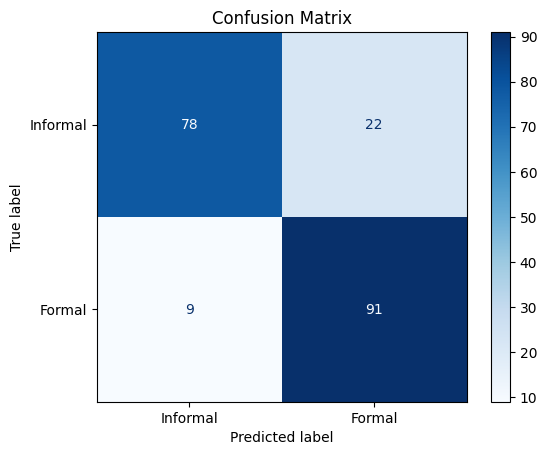

In [ ]:


cm = confusion_matrix(gt, preds)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Informal', 'Formal'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

C:\Users\timur\AppData\Local\Temp\ipykernel_21804\2252609061.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_formal, label="Formal (GT=1)", shade=True, color='blue')
C:\Users\timur\AppData\Local\Temp\ipykernel_21804\2252609061.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_informal, label="Informal (GT=0)", shade=True, color='orange')


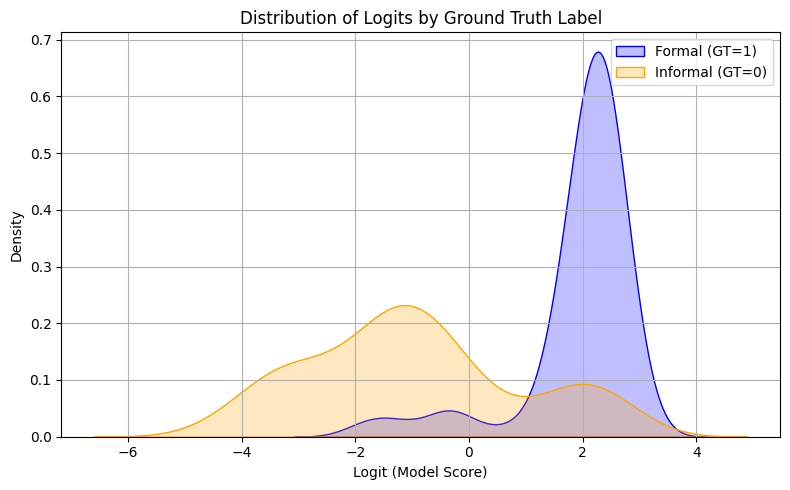

In [105]:
# Convert to NumPy arrays if not already
gt = np.array(gt)
logits = np.array(logits)

# Separate logits by ground truth labels
logits_formal = logits[gt == 1]
logits_informal = logits[gt == 0]

# Plot distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(logits_formal, label="Formal (GT=1)", shade=True, color='blue')
sns.kdeplot(logits_informal, label="Informal (GT=0)", shade=True, color='orange')

plt.title("Distribution of Logits by Ground Truth Label")
plt.xlabel("Logit (Model Score)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now we are testing performance on shorter mail with average of 25 word length to see if there is any meaningful difference in the performance.
Prompt for creating 25-word mails : please create 100 25 word formal emails that are realistic and output the results as a python list

In [114]:
formal_emails25_lengts = np.array([len(mail) for mail in formal_emails_25])
informal_emails25_lengths = np.array([len(mail) for mail in informal_emails_25])
formal_mail25_len_avg = np.mean(formal_emails25_lengts)
informal_mail25_len_avg = np.mean(informal_emails25_lengths)
print(f'Average character count of formal emails = {formal_mail25_len_avg } ')
print(f'Average character count of informal emails = {informal_mail25_len_avg } ')

Average character count of formal emails = 152.8 
Average character count of informal emails = 130.39 


In [116]:
informal_preds25 = []
formal_preds25 = []

for sample_informal in formal_emails_25:
    logit,token_attns,processed_token = lstm_model_get_prediction(sample_informal ,model_instance, word2vec_instance)
    formal_preds25.append(logit)



for sample_informal in informal_emails_25:
    logit,token_attns,processed_token = lstm_model_get_prediction(sample_informal ,model_instance, word2vec_instance)
    informal_preds25.append(logit)

formal_preds25 = np.array(formal_preds25)
informal_preds25 = np.array(informal_preds25)


formal25_preds01 = np.vectorize(logit_to_form_prediction)(formal_preds25)
formal25_gt = np.ones_like(formal25_preds01)
informal25_preds01 = np.vectorize(logit_to_form_prediction)(informal_preds25)
informal25_gt = np.zeros_like(informal25_preds01)

gt25 = np.concatenate([formal25_gt,informal25_gt])
logits25 = np.concatenate([formal_preds25,informal_preds25])
preds25 = np.concatenate([formal25_preds01 ,informal25_preds01])

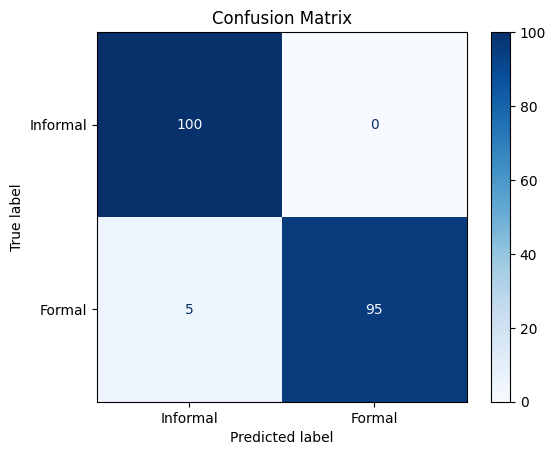

In [117]:
cm = confusion_matrix(gt25, preds25)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Informal', 'Formal'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

C:\Users\timur\AppData\Local\Temp\ipykernel_21804\2076629322.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_formal25, label="Formal (GT=1)", shade=True, color='blue')
C:\Users\timur\AppData\Local\Temp\ipykernel_21804\2076629322.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_informal25, label="Informal (GT=0)", shade=True, color='orange')


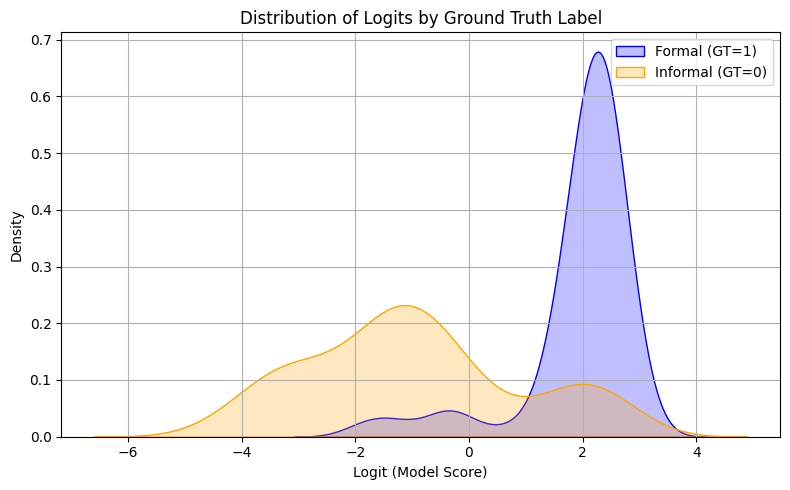

In [118]:
# Convert to NumPy arrays if not already
gt25 = np.array(gt25)
logits25 = np.array(logits25)

# Separate logits by ground truth labels
logits_formal25 = logits[gt25 == 1]
logits_informal25 = logits[gt25 == 0]

# Plot distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(logits_formal25, label="Formal (GT=1)", shade=True, color='blue')
sns.kdeplot(logits_informal25, label="Informal (GT=0)", shade=True, color='orange')

plt.title("Distribution of Logits by Ground Truth Label")
plt.xlabel("Logit (Model Score)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Edge Case Testing of model2_atn

In [10]:
edge_formal_preds = []
edge_informal_preds = []

# Predict logits for formal edge-case sentences
for sample in formal_sentences_edge:
    logit, token_attns, processed_token = lstm_model_get_prediction(sample, model_instance, word2vec_instance)
    edge_formal_preds.append(logit)

# Predict logits for informal edge-case sentences
for sample in informal_sentences_edge:
    logit, token_attns, processed_token = lstm_model_get_prediction(sample, model_instance, word2vec_instance)
    edge_informal_preds.append(logit)

# Convert lists to numpy arrays
edge_formal_preds = np.array(edge_formal_preds)
edge_informal_preds = np.array(edge_informal_preds)

# Apply thresholding or classification logic
edge_formal_preds_01 = np.vectorize(logit_to_form_prediction)(edge_formal_preds)
edge_formal_gt = np.ones_like(edge_formal_preds_01)

edge_informal_preds_01 = np.vectorize(logit_to_form_prediction)(edge_informal_preds)
edge_informal_gt = np.zeros_like(edge_informal_preds_01)

# Concatenate ground truth and predictions
gt_edge = np.concatenate([edge_formal_gt, edge_informal_gt])
logits_edge = np.concatenate([edge_formal_preds, edge_informal_preds])
preds_edge = np.concatenate([edge_formal_preds_01, edge_informal_preds_01])

In [15]:
edge_informal_preds_01 

array([0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1])

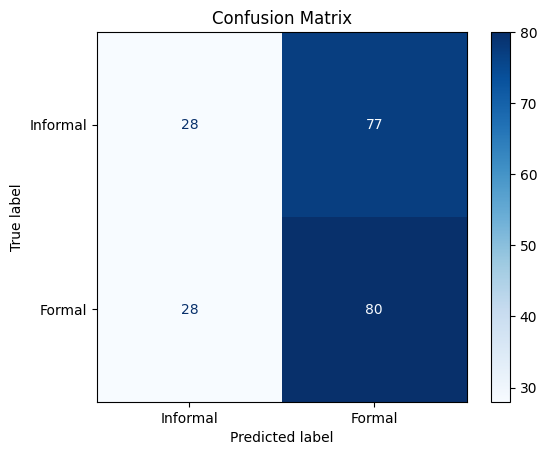

In [13]:
cm = confusion_matrix(gt_edge, preds_edge )


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Informal', 'Formal'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

C:\Users\timur\AppData\Local\Temp\ipykernel_25952\2013891872.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_formal_edge, label="Formal Edge (GT=1)", shade=True, color='blue')
C:\Users\timur\AppData\Local\Temp\ipykernel_25952\2013891872.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(logits_informal_edge, label="Informal Edge (GT=0)", shade=True, color='orange')


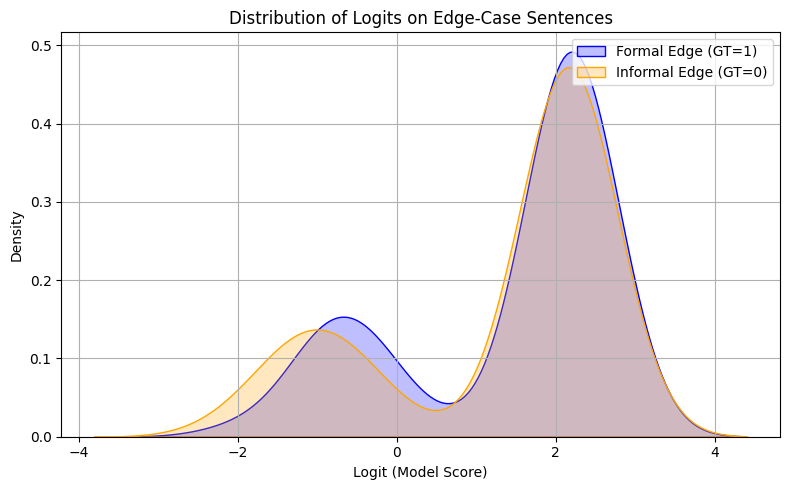

In [16]:
gt_edge = np.array(gt_edge)
logits_edge = np.array(logits_edge)

# Separate logits by ground truth labels
logits_formal_edge = logits_edge[gt_edge == 1]
logits_informal_edge = logits_edge[gt_edge == 0]

# Plot distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(logits_formal_edge, label="Formal Edge (GT=1)", shade=True, color='blue')
sns.kdeplot(logits_informal_edge, label="Informal Edge (GT=0)", shade=True, color='orange')

plt.title("Distribution of Logits on Edge-Case Sentences")
plt.xlabel("Logit (Model Score)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()